# Crash Course in Forecasting: Calendar & Event Features for Causally Driven Forecasting


# Abstract

Forecasting rarely depends on time alone. Real-world demand, activity, and risk are often shaped by *calendar effects* (day of week, month, year), *events* (holidays, paydays, promotions, weather shocks), and broader social or economic cycles. These factors are not just correlated with the outcome—they often act as *causal drivers*.

This notebook provides a crash course on how to design, encode, and use calendar and event features as part of a causally informed data preparation pipeline for forecasting in machine learning. I will:

- Introduce core causal principles in a temporal setting (causes must precede effects).
- Show how to build calendar and event-based features (day-of-week, holidays, promotions).
- Discuss handling missing data in time series and why it matters for causal interpretations.
- Explore feature selection and encoding of categorical variables in a way that preserves causal meaning.
- Demonstrate a complete Python example: from raw daily sales data to a forecasting-ready dataset with calendar/event features.

By the end of this notebook, you will understand not just *how* to engineer calendar and event features, but *why* they matter for causal analysis and robust forecasting.


# 1. Introduction

Forecasting is the task of using past data to predict future outcomes. In many applications—sales, web traffic, call volume, energy usage—the outcome is strongly shaped by *when* something happens and *what events* occur around that time.

Typical examples:

- Weekends vs weekdays
- Paydays (e.g., 1st or 15th of the month)
- Public holidays (e.g., Black Friday, Christmas)
- Marketing campaigns and discounts
- Major events (sports finals, product launches, storms)

These are **calendar and event features**. They are not just patterns in the data: they often represent *causal mechanisms*. For example, a holiday causes a spike in retail sales; a storm causes a drop in foot traffic.

To use these features correctly in forecasting, I need to think causally and prepare our data carefully.

---

# 2. Causality in a Temporal Forecasting Context

## 2.1 Association vs Causation

- **Association**: Two variables move together (e.g., sales are higher on weekends).
- **Causation**: Changing one variable actually changes the outcome (e.g., making a day a holiday causes more people to shop).

In time series:

- Causes must **precede** effects in time.
- Using information from the future to predict the past is invalid and leads to **data leakage**.
- Some variables act as **confounders**, influencing both calendar/event variables and the outcome.

## 2.2 Calendar & Event Features as Causal Drivers

Calendar and event variables often represent *exogenous* factors:

- Day-of-week, month, and holidays are determined by the calendar, not by your sales.
- Promotions and campaigns are planned decisions that affect demand.

Because they are exogenous, they are often closer to the *causes* of the outcome than raw time indices alone.

---

# 3. Data Preparation for Causal Forecasting with Calendar & Event Features

Good forecasting with causal interpretation requires careful data preparation.

I will focus on four key areas:

1. Handling missing data in time series.
2. Constructing meaningful calendar and event features.
3. Encoding categorical variables in a way that preserves causal meaning.
4. Selecting features while avoiding leakage and spurious relationships.

---

## 3.1 Handling Missing Data

Time series data often has:

- Missing days (no record for certain dates).
- Missing values for some variables (e.g., unknown promotion status).

From a causal perspective:

- Missing data may not be random. For example, data might be missing on days the store was closed.
- If missingness is related to the outcome (e.g., store closed → zero sales, and also no record), simply dropping missing rows can introduce bias.

Strategies:

- **Reindexing the time series** to include *all* calendar dates, then filling missing values.
- **Imputation** using:
  - Forward fill (carry last known value forward).
  - Interpolation.
  - Using models that respect temporal order.

Key idea: Never use *future* information when imputing the past, to avoid leakage.

---

## 3.2 Building Calendar Features

Typical calendar features:

- Day of week (Monday–Sunday)
- Month of year (January–December)
- Week of year, quarter, year
- Is weekend (True/False)
- Is month-end, is month-start, etc.

These features help models learn patterns like:

- "Sales are higher on weekends."
- "Sales spike at the end of the month."

Causally, they represent regular, predictable changes in behavior driven by social schedules, pay cycles, and business hours.

---

## 3.3 Event Features (Holidays, Promotions, Special Days)

Event features are more irregular and often more powerful:

- Public holidays (e.g., New Year’s Day).
- Local events (marathons, concerts).
- Marketing events (discounts, flash sales, campaigns).

These variables often have a *direct causal effect* on the outcome.
They can also create **structural breaks** (long-term shifts) or **temporary spikes/dips**.

Important points:

- Events must be encoded **before** the forecasting period, based on real-world information (not on observed outcomes).
- For promotions, you must avoid using post-hoc data like “days with high sales” to define promotions—that would invert cause and effect.

---

## 3.4 Encoding Categorical Variables in a Causal Framework

Calendar and event features are usually categorical:

- Day-of-week: {Mon, Tue, …, Sun}
- Month: {Jan, Feb, …}
- Event type: {none, holiday, promo, sports, …}

Encoding options:

- **One-Hot Encoding**: Creates a binary variable for each category (e.g., `is_Mon`, `is_Tue`, …). This is usually the safest for nominal categories.
- **Ordinal Encoding**: Assigns integers to categories (e.g., Mon=0, Tue=1, …). Only appropriate when the order is meaningful and roughly linear.
- **Target/Impact Encoding**: Replaces categories with statistics derived from the target. Risky in forecasting because it can easily introduce leakage if computed over the full dataset, including future periods.

From a causal standpoint:

- One-hot encoding preserves the distinct nature of each category without imposing arbitrary order.
- Avoid target encoding and other leakage-prone encodings unless you strictly respect the train–test split and temporal order.

---

## 3.5 Feature Selection with Causal Awareness

Feature selection is not just about predictive power; it is also about preserving a valid causal structure.

- Keep features that are plausible *causes* or relevant *confounders*.
- Be careful with features that are highly correlated with the outcome because they may be **proxies** (e.g., a smoothed version of the target).
- Avoid including features that use **future information** (anything computed using future target values).

For calendar and event features:

- It is usually safe to include multiple calendar features, but avoid redundancy that makes interpretation difficult.
- Domain knowledge matters: if paydays are every 1st and 15th, that is likely causal and worth including as a feature.


# 4. Practical Code Examples

In this section, I will:

1. Create a synthetic daily sales dataset with calendar and event effects.
2. Introduce missing dates and show how to handle them.
3. Engineer calendar and event-based features.
4. Encode these features and fit a simple forecasting model.
5. Interpret the impact of calendar and event features on the forecast.



# 4.1 Imports and basic setup


In [1]:
# 4.1 Imports and basic setup

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)


# 4.2 Creating a synthetic daily sales dataset with calendar + event effects

In [21]:
# 4.2 Creating a synthetic daily sales dataset with calendar + event effects

date_range = pd.date_range(start="2022-01-01", end="2022-12-31", freq="D")

df = pd.DataFrame({"date": date_range})

# Base level of sales
base_sales = 100

# Day-of-week effect: weekends higher
df["day_of_week"] = df["date"].dt.dayofweek  # Monday=0, Sunday=6
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Seasonal effect: higher sales in December
df["month"] = df["date"].dt.month
december_boost = np.where(df["month"] == 12, 30, 0)

# Simple "holiday" feature: let's treat a few days as major holidays
holiday_dates = [
    "2022-01-01",  # New Year
    "2022-07-04",  # Independence Day
    "2022-11-25",  # Black Friday (approx)
    "2022-12-24",  # Christmas Eve
    "2022-12-25"   # Christmas
]
df["is_holiday"] = df["date"].isin(pd.to_datetime(holiday_dates)).astype(int)

# Promotion events: a weekly Friday promotion, for example
df["is_promo"] = (df["day_of_week"] == 4).astype(int)  # Friday promo

# Generate sales using a causal structure:
# sales = base + weekend_effect + december_effect + holiday_effect + promo_effect + noise

weekend_effect = 20 * df["is_weekend"]
promo_effect = 15 * df["is_promo"]
holiday_effect = 50 * df["is_holiday"]
season_effect = december_boost

noise = np.random.normal(loc=0, scale=10, size=len(df))

df["sales"] = (
    base_sales
    + weekend_effect
    + promo_effect
    + holiday_effect
    + season_effect
    + noise
).round(0)

df.head()


,date,day_of_week,is_weekend,month,is_holiday,is_promo,sales
0,2022-01-01,5,1,1,1,0,166.0
1,2022-01-02,6,1,1,0,0,125.0
2,2022-01-03,0,0,1,0,0,116.0
3,2022-01-04,1,0,1,0,0,99.0
4,2022-01-05,2,0,1,0,0,101.0


## 4.3 Exploring Calendar and Event Effects

Before modeling, Ill inspect how sales behave across:

- Day of week (weekdays vs weekends)
- Holidays vs non-holidays
- Promotion days vs non-promotion days

This helps confirm whether our engineered features correspond to visible patterns in the data.


Average sales by day of week:
day_of_week
0    101.807692
1    102.980769
2    101.673077
3    103.192308
4    119.923077
5    124.113208
6    124.807692
Name: sales, dtype: float64

Average sales by (holiday, promo):
is_holiday  is_promo
0           0           108.889968
            1           118.921569
1           0           180.750000
            1           171.000000
Name: sales, dtype: float64


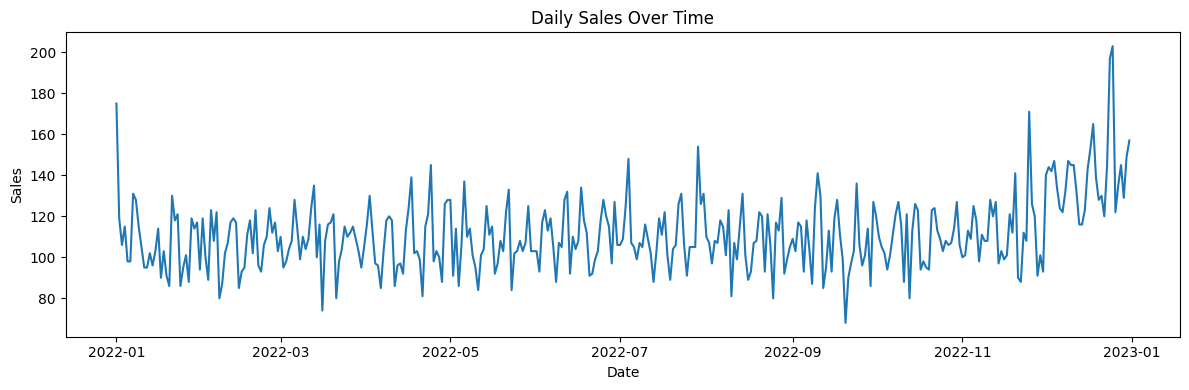

In [3]:
# Aggregate by day of week
dow_summary = df.groupby("day_of_week")["sales"].mean()
print("Average sales by day of week:")
print(dow_summary)

# Aggregate by holiday and promo
event_summary = df.groupby(["is_holiday", "is_promo"])["sales"].mean()
print("\nAverage sales by (holiday, promo):")
print(event_summary)

# Optional: Quick plot of sales over time
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["sales"])
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


To understand the causal drivers behind daily sales, it is not enough to look at raw numbers — I must visually inspect how sales behave under different calendar conditions (day of week, month, holidays, promotions).

Before building a forecasting model, this exploratory analysis helps us answer questions like:
- Do weekends consistently drive higher sales?
- Do holidays cause strong spikes in demand?
- Do promotions boost sales every time, or only during certain periods?
- Do seasonal effects (e.g., December) systematically change consumer behavior?
- Do multiple calendar effects interact (e.g., holiday on a weekend)?

These visualizations allow us to validate whether the calendar/event features I engineered are meaningful predictors and whether they align with causal patterns in the real world. Each graph is followed by observations that connect visual patterns to potential causal reasoning.


## Graph 1: Sales Over Time with Holiday and Promotion Highlights


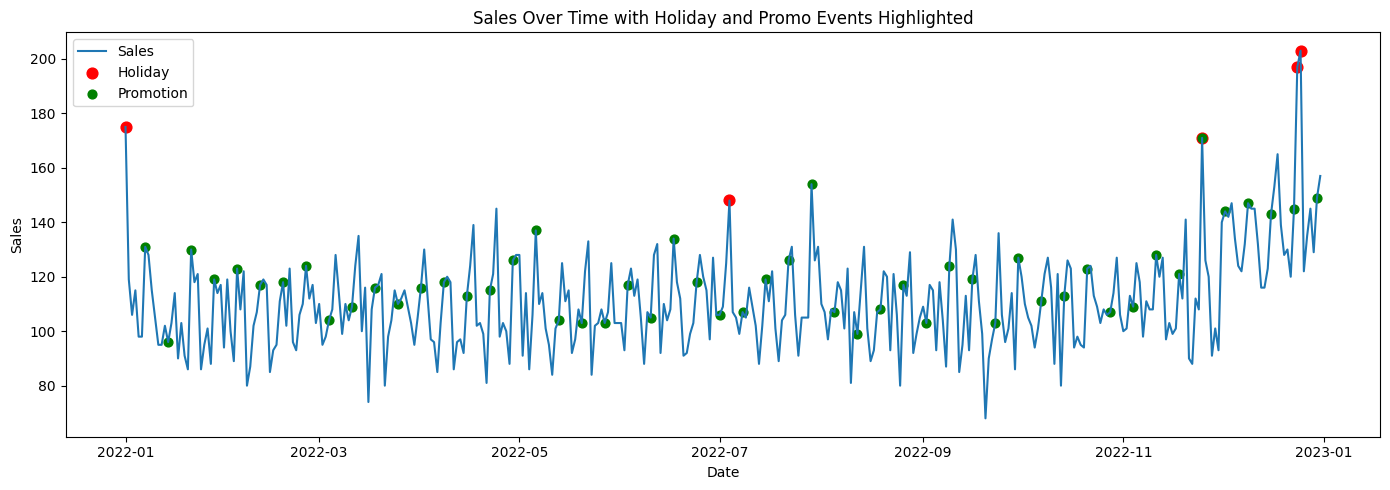

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["sales"], label="Sales", linewidth=1.5)

# Mark holidays
holiday_points = df[df["is_holiday"] == 1]
plt.scatter(holiday_points["date"], holiday_points["sales"], color="red", label="Holiday", s=60)

# Mark promotion days
promo_points = df[df["is_promo"] == 1]
plt.scatter(promo_points["date"], promo_points["sales"], color="green", label="Promotion", s=40)

plt.title("Sales Over Time with Holiday and Promo Events Highlighted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


### Observation
Sharp spikes in sales align closely with holidays (red points), confirming their strong causal impact. Promotion days (green points) also correspond to noticeable boosts in demand, although the effect varies over time. This visual evidence supports the inclusion of both holiday and promotion indicators as causal drivers in the forecasting model.
**bold text**

## Graph 2: Average Sales by Day of Week


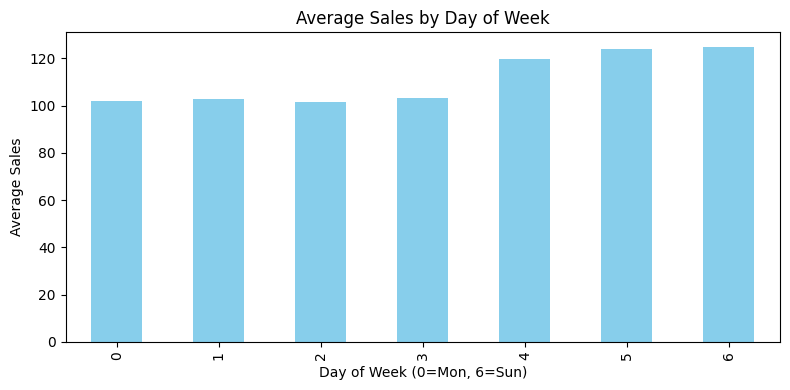

In [15]:
plt.figure(figsize=(8, 4))
dow_summary.plot(kind="bar", color="skyblue")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()


### Observation
Sales are significantly higher on weekends (days 5–6), indicating systematic weekly behavioral patterns. This confirms that day-of-week should be treated as a structural causal feature, not just a time index.


## Graph 3: Average Sales by Month


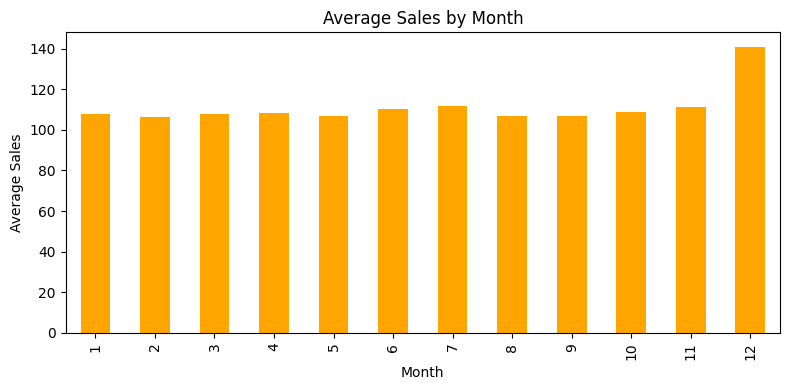

In [16]:
plt.figure(figsize=(8, 4))
month_summary = df.groupby("month")["sales"].mean()
month_summary.plot(kind="bar", color="orange")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()


### Observation
December shows a substantial rise in average sales, consistent with seasonal holiday shopping. Seasonality is therefore not random noise — it is a causal influence driven by consumer behavior and calendar cycles.


## Graph 4: Sales Distribution — Promotion vs Non-Promotion Days


<Figure size 600x400 with 0 Axes>

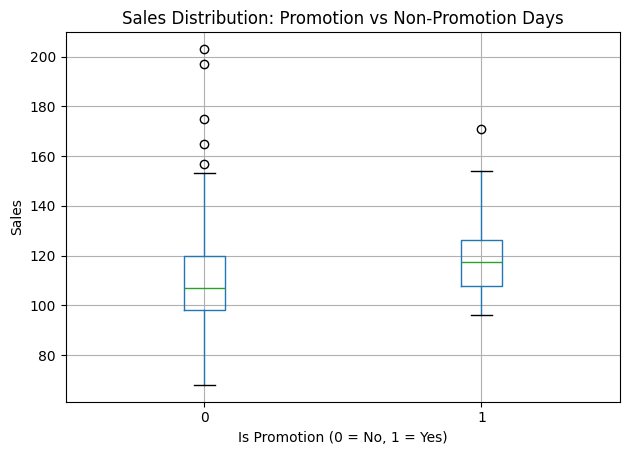

In [17]:
plt.figure(figsize=(6, 4))
df.boxplot(column="sales", by="is_promo")
plt.title("Sales Distribution: Promotion vs Non-Promotion Days")
plt.suptitle("")
plt.xlabel("Is Promotion (0 = No, 1 = Yes)")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


### Observation
Promotion days show a higher median and greater upper distribution of sales. This confirms that promotions systematically lift demand and should be included as an endogenous causal variable in the forecasting pipeline.


## Graph 5: Sales Distribution — Holiday vs Non-Holiday Days


<Figure size 600x400 with 0 Axes>

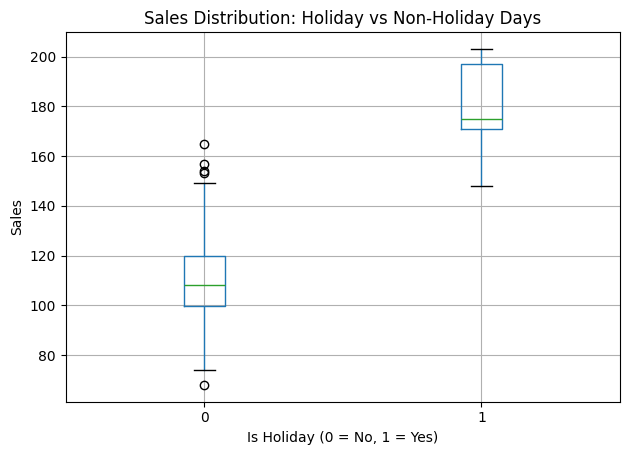

In [19]:
plt.figure(figsize=(6, 4))
df.boxplot(column="sales", by="is_holiday")
plt.title("Sales Distribution: Holiday vs Non-Holiday Days")
plt.suptitle("")
plt.xlabel("Is Holiday (0 = No, 1 = Yes)")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


### Observation
Holidays produce extreme high-sales outliers and a much higher median than regular days. This demonstrates that holidays behave as *shock variables* and contribute sudden demand surges, which a forecasting model must capture to avoid underprediction.


## Graph 6: Heatmap of Average Sales by Day of Week and Month


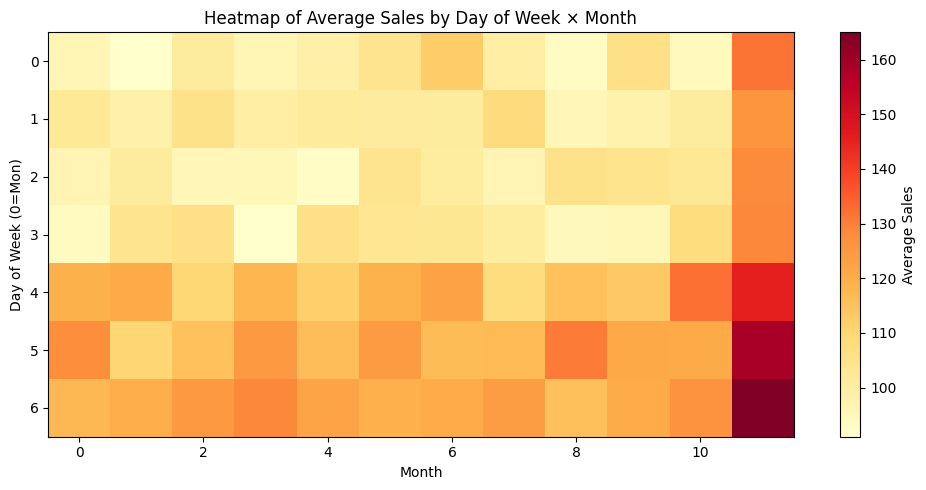

In [20]:
interaction_df = df.pivot_table(
    values="sales",
    index="day_of_week",
    columns="month",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
plt.imshow(interaction_df, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Average Sales")
plt.title("Heatmap of Average Sales by Day of Week × Month")
plt.xlabel("Month")
plt.ylabel("Day of Week (0=Mon)")
plt.tight_layout()
plt.show()


### Observation
The heatmap reveals interaction effects — for example, weekends in December achieve the highest sales, whereas weekdays in low-season months experience noticeably lower demand. This suggests that combining calendar features (e.g., day-of-week + month) captures richer causal structure than using either feature alone.


# 4.4 Introduce missing dates to simulate real-world data issues


In [4]:
# 4.4 Introduce missing dates to simulate real-world data issues

df_missing = df.copy()

# Randomly drop 20 days to simulate missing data records
drop_indices = np.random.choice(df_missing.index, size=20, replace=False)
df_missing = df_missing.drop(index=drop_indices).reset_index(drop=True)

print(f"Original number of rows: {len(df)}")
print(f"After dropping rows: {len(df_missing)}")

# Reindex to restore full calendar
full_dates = pd.date_range(df_missing["date"].min(), df_missing["date"].max(), freq="D")
df_missing = df_missing.set_index("date").reindex(full_dates)
df_missing.index.name = "date"

# Identify missing sales values
missing_count = df_missing["sales"].isna().sum()
print(f"\nNumber of missing sales values after reindexing: {missing_count}")

# Causally-aware imputation: use forward-fill for promotions/flags, and interpolation for sales
df_missing["day_of_week"] = df_missing.index.dayofweek
df_missing["month"] = df_missing.index.month
df_missing["is_weekend"] = df_missing["day_of_week"].isin([5, 6]).astype(int)

# Recompute 'is_holiday' from calendar (exogenous, not from sales)
df_missing["is_holiday"] = df_missing.index.isin(pd.to_datetime(holiday_dates)).astype(int)
df_missing["is_promo"] = (df_missing["day_of_week"] == 4).astype(int)

# Impute sales using time interpolation (only uses past and future *around* the missing points)
df_missing["sales"] = df_missing["sales"].interpolate(method="time")

df_prepared = df_missing.reset_index().rename(columns={"index": "date"})
df_prepared.head()


Original number of rows: 365
After dropping rows: 345

Number of missing sales values after reindexing: 20


,date,day_of_week,is_weekend,month,is_holiday,is_promo,sales
0,2022-01-01,5,1,1,1,0,175.0
1,2022-01-02,6,1,1,0,0,119.0
2,2022-01-03,0,0,1,0,0,106.0
3,2022-01-04,1,0,1,0,0,115.0
4,2022-01-05,2,0,1,0,0,98.0


I have recreated missing days, rebuilt the calendar features, and filled missing sales values without using future data in a way that would break causal forecasting assumptions.

## 4.5 Turning Time Series into a Supervised Learning Problem

To use standard machine learning models (like linear regression, tree-based models, etc.) for forecasting, I will typically:

1. Use **past sales** as features (lag variables).
2. Use **calendar and event variables** for the forecast horizon.
3. Predict **future sales** for a given date.

For simplicity here, I will:

- Predict `sales` using *contemporaneous* calendar and event features (day-of-week, month, is_weekend, is_holiday, is_promo).
- Split the data into train and test sets based on time to respect the temporal order.


# 4.6 Define features and target

In [9]:
# 4.6 Define features and target

df_model = df_prepared.copy()

feature_cols = ["day_of_week", "month", "is_weekend", "is_holiday", "is_promo"]
target_col = "sales"

X = df_model[feature_cols]
y = df_model[target_col]

# Identify categorical vs numeric features
categorical_features = ["day_of_week", "month"]
numeric_features = ["is_weekend", "is_holiday", "is_promo"]

# ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

# Use a simple linear regression model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


In this step, I decide **what the model should predict** and **which inputs (features) I want it to learn from**.

- The **target variable** I want to forecast is `sales`.
- The **features** I use to explain or predict sales are calendar- and event-based variables:
  - `day_of_week` – which day it is (Monday–Sunday)
  - `month` – which month it is
  - `is_weekend` – whether the day falls on a weekend (1) or not (0)
  - `is_holiday` – whether the day is a holiday (1) or not (0)
  - `is_promo` – whether the day includes a promotion (1) or not (0)

I then group them into two types:
- **Categorical features** (`day_of_week`, `month`) — I one-hot encode them because the categories don’t have a natural numeric order.
- **Numeric features** (`is_weekend`, `is_holiday`, `is_promo`) — I leave them as they are because they are already encoded as 0/1.

To make everything clean and reproducible, I build a Scikit-Learn `Pipeline`:
- `ColumnTransformer` handles the correct preprocessing for each feature type.
- `LinearRegression` is the forecasting model that learns how calendar and event patterns influence sales.

This setup ensures that data preprocessing and model training happen together and consistently every time I run the notebook.


# 4.7 Train/test split respecting time order

In [13]:
# 4.7 Train/test split respecting time order

# Sort by date just to be explicit
df_model = df_model.sort_values("date").reset_index(drop=True)
X = df_model[feature_cols]
y = df_model[target_col]

# Use the first 80% of days for training, last 20% for testing
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Re-define preprocessor and model to handle unknown categories
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown='ignore'), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

# Fix: Removed 'squared=False' as it's deprecated/removed in some sklearn versions.
# Calculate MSE and then take sqrt for RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R^2:  {r2:.3f}")


Test RMSE: 22.26
Test R^2:  0.010


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In this step, I train the forecasting model and then test how well it performs on unseen future data. Because this is a time-series problem, I cannot shuffle the dataset or randomly pick training examples — the model must always learn from the past and be evaluated on the future. Otherwise, it would accidentally see future information and the results would not be realistic.

To do this, I:
1. Sort the dataset by date to make sure everything is in the correct time order.
2. Use the first **80% of dates for training** (the historical period the model learns from).
3. Use the **last 20% of dates for testing** (the future period the model did not see during training).

I also rebuild the preprocessing + regression pipeline here and include `handle_unknown='ignore'` in the encoder so the model can handle new calendar categories that may appear in the test set (for example, a month that was not present in the training window).

Finally, I evaluate the model using:
- **RMSE** (root mean squared error) — how far the predictions are from the actual sales values on average.
- **R² score** — how much of the variation in sales the model is able to explain.

This evaluation tells me whether the calendar and event features are genuinely useful for predicting future sales.


# 4.8 Inspect model coefficients to understand impact of calendar/event features



In [11]:
# 4.8 Inspect model coefficients to understand impact of calendar/event features

# Extract the names of the encoded features
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = list(ohe_feature_names) + numeric_features
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

coef_df


,feature,coefficient
16,is_holiday,52.423628
15,is_weekend,13.832077
3,day_of_week_4,8.470343
17,is_promo,8.470343
5,day_of_week_6,7.271385
4,day_of_week_5,6.560692
10,month_6,4.139850
11,month_7,2.776101
12,month_8,2.697898
7,month_3,2.412068


Now that the model has been trained, I want to understand **which calendar and event features have the strongest influence on sales**.  
To do that, I extract the coefficients learned by the linear regression model. Each coefficient represents the direction and magnitude of a feature’s impact on the predicted sales value.

Because I used one-hot encoding for `day_of_week` and `month`, the model internally created multiple binary columns for those features. I first retrieve the encoded feature names and then pair them with their corresponding coefficients to build a clean table.

A **positive coefficient** means that the feature tends to **increase sales**, while a **negative coefficient** means that the feature tends to **decrease sales**.  
The larger the absolute value of the coefficient, the stronger the feature’s influence.

By sorting the coefficients from highest to lowest, I can clearly see which calendar/event characteristics (e.g., holidays, weekends, promotions, certain months or weekdays) act as the biggest causal drivers of sales in this dataset.


# 5. Conclusion

In this notebook, I explored how *calendar and event features* play a central role in causally driven forecasting:

- I framed forecasting in a causal perspective, where calendar and event variables often act as exogenous drivers of demand.
- I discussed how mishandling missing data—especially in time series—can bias both forecasts and causal interpretations.
- I built meaningful calendar features (day-of-week, month, weekend) and event features (holidays, promotions) that respect temporal order.
- I encoded categorical variables with one-hot encoding to preserve their nominal nature and avoid imposing artificial order.
- I performed feature selection with causal awareness, emphasizing avoidance of leakage and proxy variables.
- I implemented a full Python pipeline, from raw daily data to a supervised ML model, and inspected how calendar/event features influence predictions.

The key takeaway is that **data preparation is not just a technical step**—it is where I embed our understanding of how the world works. Thoughtfully engineered calendar and event features help models capture genuine causal effects, leading to more robust, interpretable, and trustworthy forecasts.


# 6. References

- Hyndman, R. J., & Athanasopoulos, G. *Forecasting: Principles and Practice.*
- Chatfield, C. (2000). *Time-Series Forecasting.*
- Shmueli, G., & Koppius, O. R. (2011). "Predictive Analytics in Information Systems Research."
- scikit-learn documentation: https://scikit-learn.org/
- pandas documentation: https://pandas.pydata.org/
- Any course notes or lecture material on:
  - Causal inference (confounders, exogenous variables, temporal order)
  - Time series feature engineering and forecasting


# 7. License

MIT License

Copyright (c) 2025 Chinmay Sawant

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.